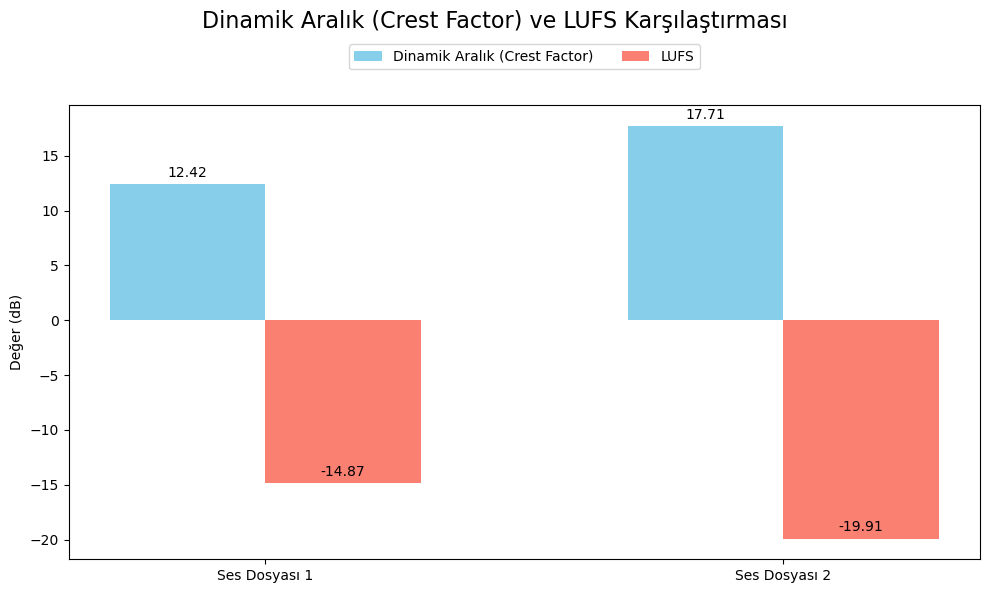

In [11]:
# Kütüphaneler ve işleme araçları
import matplotlib.pyplot as plt
import numpy as np
import librosa
import pyloudnorm as pyln

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav"
file_2 = "/Users/nazimerensahin/Desktop/2.wav"

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1"
label_2 = "Ses Dosyası 2"

# Ses dosyalarını yükleme
wave_1, sr_1 = librosa.load(file_1, sr=None)
wave_2, sr_2 = librosa.load(file_2, sr=None)

# LUFS analiz aracı
meter = pyln.Meter(sr_1)

# Ses dosyalarını yükleme
wave_1, sr_1 = librosa.load(file_1, sr=None)
wave_2, sr_2 = librosa.load(file_2, sr=None)

# Dinamik Aralık (Crest Factor) Hesaplama
max_1 = np.max(np.abs(wave_1))
rms_1 = np.sqrt(np.mean(wave_1 ** 2))
max_2 = np.max(np.abs(wave_2))
rms_2 = np.sqrt(np.mean(wave_2 ** 2))

# Crest Factor (Dinamik Aralık) hesapla
cf_1 = 20 * np.log10(max_1 / rms_1) if rms_1 > 0 else -np.inf
tcf_2 = 20 * np.log10(max_2 / rms_2) if rms_2 > 0 else -np.inf

# LUFS Hesaplama
lufs_1 = meter.integrated_loudness(wave_1)
lufs_2 = meter.integrated_loudness(wave_2)

# Grafik Çizimi
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(2)
width = 0.3

# Çubuk grafiğini çizdirme ve etiketleri ekleme
bar1 = ax.bar(x - width/2, [cf_1, tcf_2], width, 
label="Dinamik Aralık (Crest Factor)", color='skyblue')
bar2 = ax.bar(x + width/2, [lufs_1, lufs_2], width, 
              label="LUFS", color='salmon')

# Sütunların üzerine değer etiketlerini ekleme
for bars in [bar1, bar2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', 
xy=(bar.get_x() + bar.get_width() / 2, height), 
xytext=(0, 3), # Y ekseninden 3 birim yukarı
textcoords="offset points", 
ha='center', va='bottom') 

# Eksen etiketleri ve başlıkları
ax.set_ylabel("Değer (dB)")
ticks = [label_1, label_2]
ax.set_xticks(x)
ax.set_xticklabels(ticks)
ax.legend(loc='upper center', 
          bbox_to_anchor=(0.5, 1.15), ncol=2)

# Grafik düzenini ayarla ve gösterme
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle("Dinamik Aralık (Crest Factor) ve LUFS Karşılaştırması", 
             fontsize=16)
plt.show()